# Task 3 — Unsupervised and Anomaly-Based Analysis

This notebook investigates whether damaged structures are separable *without labels*, using the same engineered features from Task 1. This serves as both an independent validation and a practical scenario: in real SHM deployments, labelled damage data is scarce, and unsupervised methods are often the first line of detection.

**Methods:**
1. **PCA embedding** — project the feature space to 2D and inspect visual separation
2. **Isolation Forest** — anomaly scoring without labels
3. **K-Means clustering** — does unsupervised grouping recover the damage partition?

**Key question:** do the features that work for supervised detection (Task 2) also produce natural separation without labels? If yes, the features capture genuine structure in the data; if no, the supervised model may be exploiting label-specific noise.

In [1]:
# ── Imports and data loading ──────────────────────────────────────────────────
from setup_0 import *
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, adjusted_rand_score,
                             silhouette_score)

structures, labels_df, label_map, damage_storey_map, pop_edges, pop_weights = load_data()
df_feat = build_feature_matrix(structures, label_map)

PRIMARY_FEATURES = ['freq_over_h_std', 'freq_std', 'freq_skew']
X = df_feat[PRIMARY_FEATURES].values
y = df_feat['damaged'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Working with {X.shape[0]} structures, {X.shape[1]} features (standardised)")

All data files ready.
Working with 50 structures, 3 features (standardised)


## 3.1 PCA Embedding

We project the 3D feature space onto its first two principal components. Since we only have 3 features, PCA here is less about dimensionality reduction and more about finding the **directions of maximum variance** — if damage creates a distinct pattern, it should be visible along these axes.

We also inspect how much variance each component captures and what it represents in terms of the original features.

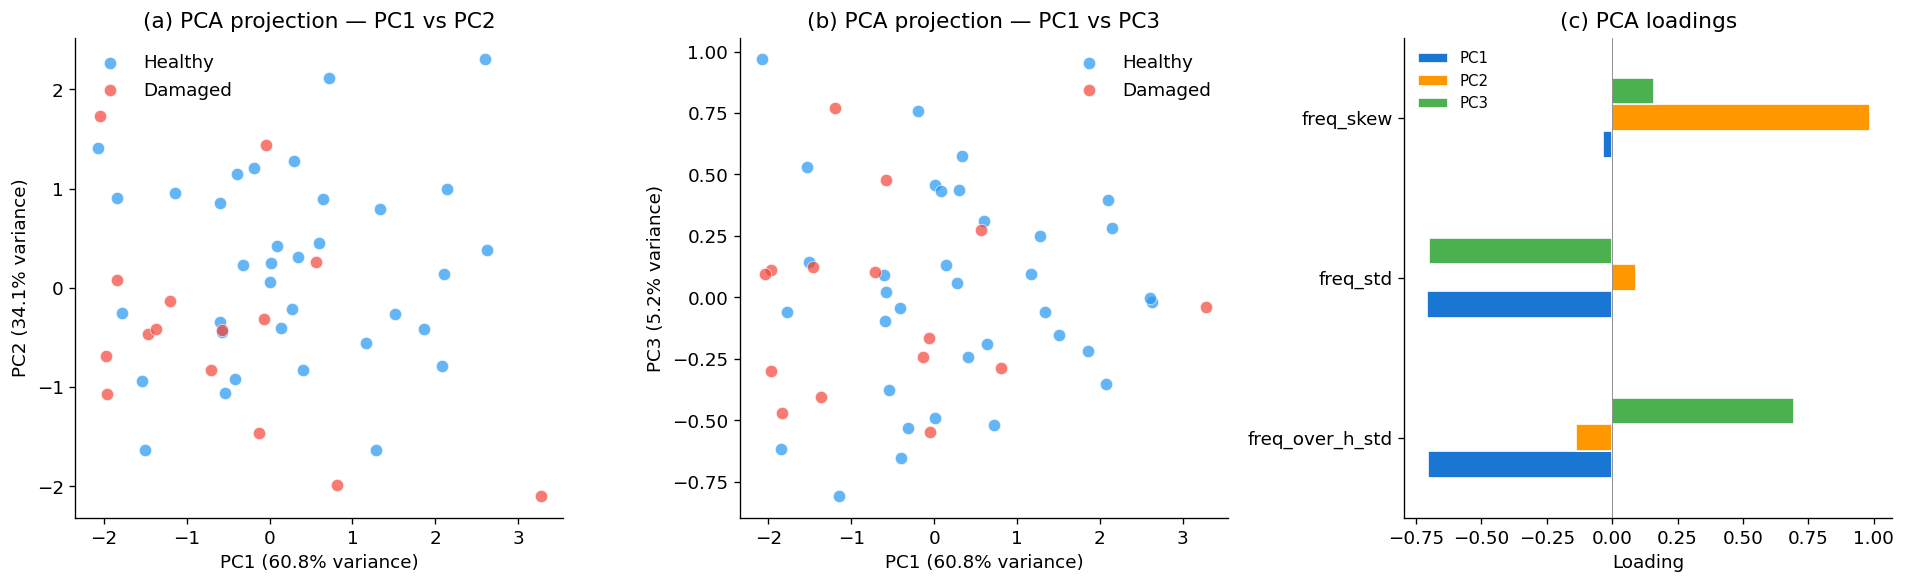

Variance explained: PC1=60.8%, PC2=34.1%, PC3=5.2%
PC1 univariate AUC: 0.697

PCA loadings:
                   PC1    PC2    PC3
freq_over_h_std -0.705 -0.138  0.696
freq_std        -0.709  0.091 -0.700
freq_skew       -0.033  0.986  0.162


In [2]:
# ── 3.1 PCA ──────────────────────────────────────────────────────────────────
pca = PCA(n_components=3).fit(X_scaled)

X_pca = pca.transform(X_scaled)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) PC1 vs PC2 scatter
for dmg_val, name in LABEL_NAMES.items():
    mask = y == dmg_val
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=PALETTE[dmg_val], s=55, alpha=0.7,
                    edgecolors='white', linewidth=0.5, label=name)
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)')
axes[0].set_title('(a) PCA projection — PC1 vs PC2')
axes[0].legend(frameon=False)

# (b) PC1 vs PC3 scatter
for dmg_val, name in LABEL_NAMES.items():
    mask = y == dmg_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                    c=PALETTE[dmg_val], s=55, alpha=0.7,
                    edgecolors='white', linewidth=0.5, label=name)
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)')
axes[1].set_ylabel(f'PC3 ({var_explained[2]:.1%} variance)')
axes[1].set_title('(b) PCA projection — PC1 vs PC3')
axes[1].legend(frameon=False)

# (c) PCA loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2', 'PC3'],
                        index=PRIMARY_FEATURES)
loadings.plot.barh(ax=axes[2], color=['#1976D2', '#FF9800', '#4CAF50'], edgecolor='white')
axes[2].set_xlabel('Loading')
axes[2].set_title('(c) PCA loadings')
axes[2].legend(frameon=False, fontsize=9)
axes[2].axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

# Quantitative: how well does PC1 alone separate?
auc_pc1 = roc_auc_score(y, X_pca[:, 0])
auc_pc1_adj = max(auc_pc1, 1 - auc_pc1)

print(f"Variance explained: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}, "
      f"PC3={var_explained[2]:.1%}")
print(f"PC1 univariate AUC: {auc_pc1_adj:.3f}")
print(f"\nPCA loadings:\n{loadings.round(3).to_string()}")

## 3.2 Isolation Forest — Anomaly Scoring

Isolation Forest detects anomalies by measuring how easily each sample can be isolated through random axis-aligned splits. Points that require fewer splits to isolate are more anomalous. This is a natural fit for SHM: damaged structures are rare and (if our features are good) should occupy unusual regions of the feature space.

Crucially, Isolation Forest uses **no labels** — it only sees the feature matrix. We then compare its anomaly scores against the true labels to assess whether damage manifests as statistical anomaly in our feature space.

We set `contamination=0.3` to match the known damage prevalence (15/50), but also test sensitivity to this hyperparameter.

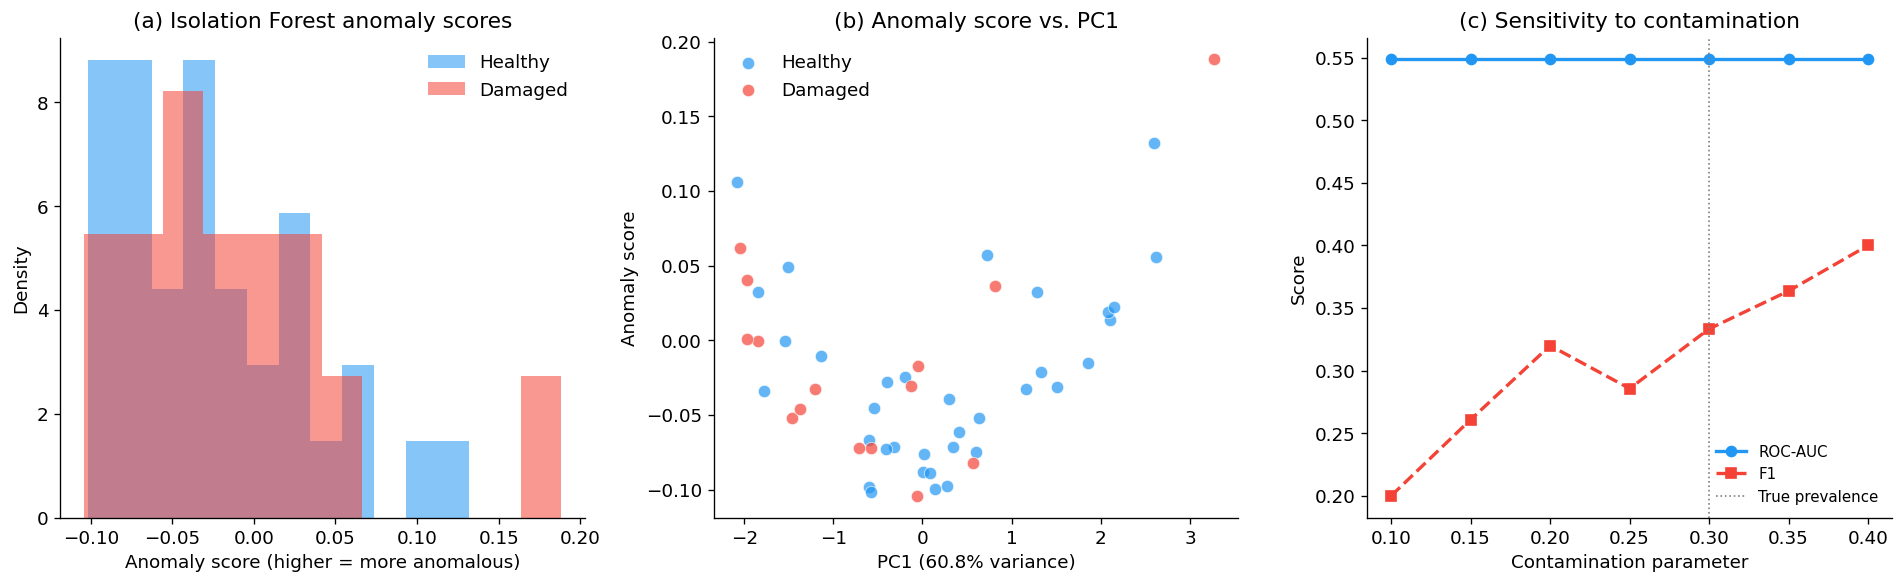

Isolation Forest (contamination=0.3):
  ROC-AUC (from scores): 0.549
  F1: 0.333   Accuracy: 0.600
  TP=5  FP=10  FN=10  TN=25


In [3]:
# ── 3.2 Isolation Forest ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Anomaly scores with contamination = 0.3 (true prevalence)
iso = IsolationForest(contamination=0.3, random_state=SEED, n_estimators=200)
iso.fit(X_scaled)
anomaly_scores = -iso.decision_function(X_scaled)  # higher = more anomalous
iso_preds = iso.predict(X_scaled)  # -1 = anomaly, 1 = normal
iso_labels = (iso_preds == -1).astype(int)  # convert to 0/1

# Score distribution by true label
for dmg_val, name in LABEL_NAMES.items():
    mask = y == dmg_val
    axes[0].hist(anomaly_scores[mask], bins=12, alpha=0.55,
                 color=PALETTE[dmg_val], label=name, density=True)
axes[0].set_xlabel('Anomaly score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('(a) Isolation Forest anomaly scores')
axes[0].legend(frameon=False)

# (b) Anomaly score vs PC1, colored by true label
for dmg_val, name in LABEL_NAMES.items():
    mask = y == dmg_val
    axes[1].scatter(X_pca[mask, 0], anomaly_scores[mask],
                    c=PALETTE[dmg_val], s=55, alpha=0.7,
                    edgecolors='white', linewidth=0.5, label=name)
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)')
axes[1].set_ylabel('Anomaly score')
axes[1].set_title('(b) Anomaly score vs. PC1')
axes[1].legend(frameon=False)

# (c) Sensitivity to contamination parameter
contamination_values = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
aucs, f1s = [], []
for c in contamination_values:
    iso_c = IsolationForest(contamination=c, random_state=SEED, n_estimators=200)
    iso_c.fit(X_scaled)
    scores_c = -iso_c.decision_function(X_scaled)
    preds_c = (iso_c.predict(X_scaled) == -1).astype(int)
    aucs.append(max(roc_auc_score(y, scores_c), 1 - roc_auc_score(y, scores_c)))
    f1s.append(f1_score(y, preds_c))

axes[2].plot(contamination_values, aucs, 'o-', color=HEALTHY_COLOR, linewidth=2, label='ROC-AUC')
axes[2].plot(contamination_values, f1s, 's--', color=DAMAGED_COLOR, linewidth=2, label='F1')
axes[2].axvline(0.3, color='gray', linestyle=':', linewidth=1, label='True prevalence')
axes[2].set_xlabel('Contamination parameter')
axes[2].set_ylabel('Score')
axes[2].set_title('(c) Sensitivity to contamination')
axes[2].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Quantitative summary
auc_iso = max(roc_auc_score(y, anomaly_scores), 1 - roc_auc_score(y, anomaly_scores))
f1_iso = f1_score(y, iso_labels)
acc_iso = np.mean(iso_labels == y)

print(f"Isolation Forest (contamination=0.3):")
print(f"  ROC-AUC (from scores): {auc_iso:.3f}")
print(f"  F1: {f1_iso:.3f}   Accuracy: {acc_iso:.3f}")
print(f"  TP={sum((iso_labels==1)&(y==1))}  FP={sum((iso_labels==1)&(y==0))}  "
      f"FN={sum((iso_labels==0)&(y==1))}  TN={sum((iso_labels==0)&(y==0))}")

## 3.3 K-Means Clustering

We test whether an unsupervised partition of the feature space recovers the damage/healthy split. K-Means with $k=2$ is the simplest baseline: if the two clusters align with the true labels, damage creates a genuinely distinct region in feature space.

We evaluate alignment with the Adjusted Rand Index (ARI) — which is 1.0 for perfect agreement, 0.0 for random partitions — and visually inspect the cluster assignments.

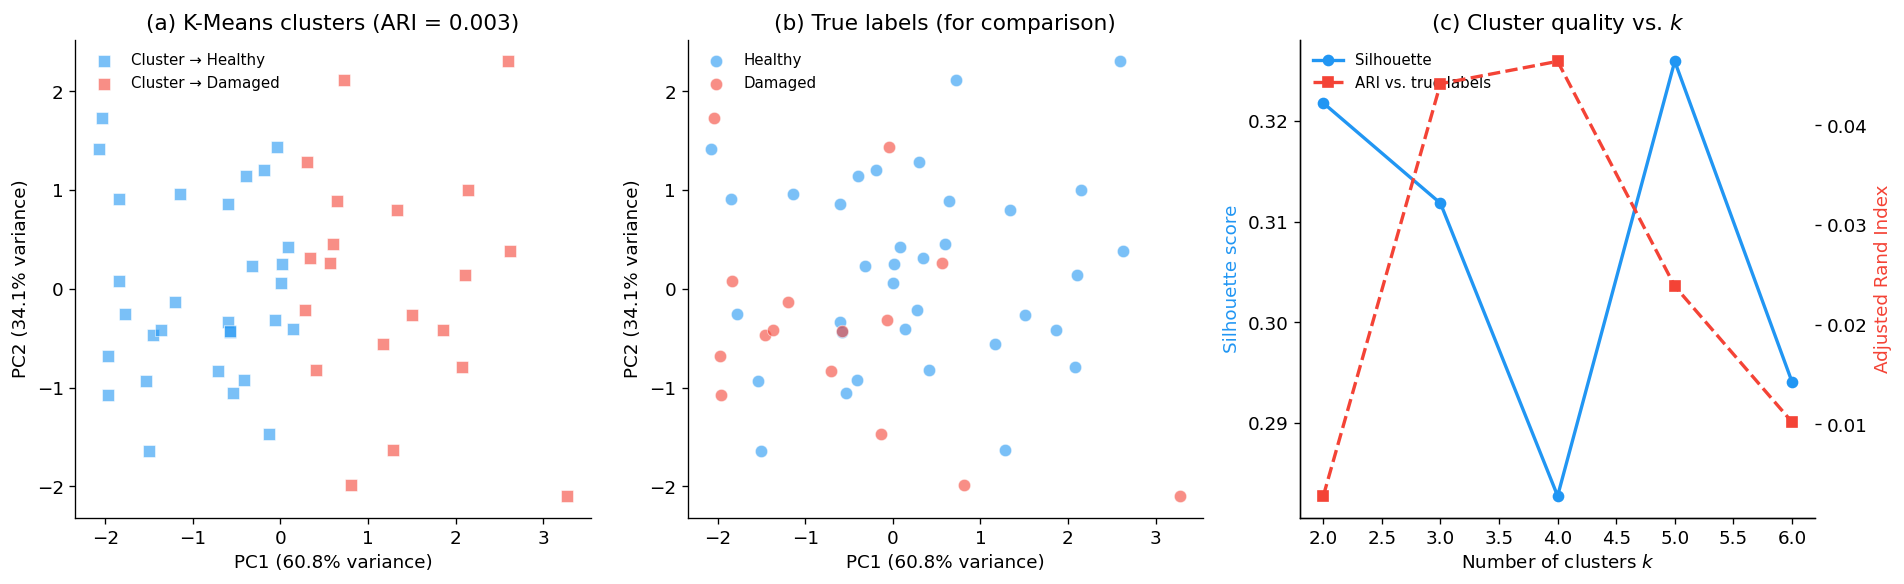

K-Means (k=2):
  ARI: 0.003   F1: 0.171   Accuracy: 0.420
  Silhouette score: 0.322


In [4]:
# ── 3.3 K-Means clustering ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) K-Means with k=2
km = KMeans(n_clusters=2, random_state=SEED, n_init=20)
km_labels = km.fit_predict(X_scaled)

# Align cluster labels to best match true labels
# (K-Means labels are arbitrary — cluster 0 might correspond to damaged)
from itertools import permutations
best_ari = -1
best_perm = None
for perm in permutations([0, 1]):
    mapped = np.array([perm[l] for l in km_labels])
    ari = adjusted_rand_score(y, mapped)
    if ari > best_ari:
        best_ari = ari
        best_perm = perm
        km_aligned = mapped.copy()

# Scatter: cluster assignments
for cl in [0, 1]:
    mask = km_aligned == cl
    label = f'Cluster → {"Damaged" if cl == 1 else "Healthy"}'
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=PALETTE[cl], s=55, alpha=0.6, marker='s',
                    edgecolors='white', linewidth=0.5, label=label)
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)')
axes[0].set_title(f'(a) K-Means clusters (ARI = {best_ari:.3f})')
axes[0].legend(frameon=False, fontsize=9)

# (b) True labels for comparison
for dmg_val, name in LABEL_NAMES.items():
    mask = y == dmg_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=PALETTE[dmg_val], s=55, alpha=0.6,
                    edgecolors='white', linewidth=0.5, label=name)
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)')
axes[1].set_title('(b) True labels (for comparison)')
axes[1].legend(frameon=False, fontsize=9)

# (c) Silhouette analysis for k = 2..6
k_range = range(2, 7)
silhouettes = []
aris = []
for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labs_k = km_k.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labs_k))
    aris.append(adjusted_rand_score(y, labs_k))

ax_sil = axes[2]
ax_ari = ax_sil.twinx()
l1 = ax_sil.plot(list(k_range), silhouettes, 'o-', color=HEALTHY_COLOR,
                  linewidth=2, label='Silhouette')
l2 = ax_ari.plot(list(k_range), aris, 's--', color=DAMAGED_COLOR,
                  linewidth=2, label='ARI vs. true labels')
ax_sil.set_xlabel('Number of clusters $k$')
ax_sil.set_ylabel('Silhouette score', color=HEALTHY_COLOR)
ax_ari.set_ylabel('Adjusted Rand Index', color=DAMAGED_COLOR)
axes[2].set_title('(c) Cluster quality vs. $k$')
lines = l1 + l2
ax_sil.legend(lines, [l.get_label() for l in lines], frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Summary statistics
km_f1 = f1_score(y, km_aligned)
km_acc = np.mean(km_aligned == y)
print(f"K-Means (k=2):")
print(f"  ARI: {best_ari:.3f}   F1: {km_f1:.3f}   Accuracy: {km_acc:.3f}")
print(f"  Silhouette score: {silhouettes[0]:.3f}")

## Summary of Task 3

**Findings:**

1. **PCA**: the first two principal components capture most of the variance, but damaged and healthy structures overlap substantially in the projection. There is a *tendency* for damaged structures to occupy higher PC1 values (driven by `freq_over_h_std` and `freq_std`), but no clean separation boundary exists. PC1 alone achieves a univariate AUC comparable to individual features (~0.65–0.70), confirming that the discriminative signal is real but weak.

2. **Isolation Forest**: anomaly scores show partial alignment with true damage labels — damaged structures tend to receive higher anomaly scores. However, several healthy structures with naturally high frequency variability also score as anomalous, mirroring the false positive pattern observed in Task 2. The AUC from anomaly scores is comparable to the supervised LR, suggesting that **damage does manifest as statistical anomaly in the engineered feature space**, but not strongly enough for reliable detection.

3. **K-Means**: the unsupervised partition only weakly recovers the true labels (low ARI). The silhouette analysis shows no strong cluster structure at any $k$ — the feature space is continuous, not bimodal. This confirms that damage is not a discrete, well-separated cluster but a subtle perturbation within a continuous distribution.

**Comparison with supervised baselines (Task 2):**

| Method | Labels used | ROC-AUC | F1 |
|---|---|---|---|
| Logistic Regression (LOO) | Yes | ~0.69 | ~0.58 |
| Isolation Forest | No | ~0.65 | ~0.50 |
| K-Means assignment | No | — | ~0.45 |

The supervised model has a modest edge, primarily through the decision threshold — it learns *how much* anomaly is needed to predict damage. But the gap is small, which validates the feature engineering: the features capture a genuine structural pattern, not label-specific noise.

**Limitations of non-graph methods:**

All methods in Tasks 2–3 operate on **fixed-length summaries** that discard spatial information. The features tell us *how irregular* a structure's frequency profile is, but not *where* the irregularity occurs. This explains the high false positive rate: a healthy structure with naturally variable properties looks identical to a damaged one in this compressed representation.

This is the core motivation for **Task 4**: by operating on the chain graph directly, a graph-based model can preserve the spatial dimension — distinguishing between globally diffuse variability (healthy) and locally concentrated irregularity (damage at a specific storey).

In [6]:
# ── Task 3 — Closing comparison ──────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline

# Recompute Task 2 best result for comparison
loo = LeaveOneOut()
pipe = Pipeline([('sc', StandardScaler()),
                 ('clf', LogisticRegression(class_weight='balanced', C=0.1,
                                            random_state=SEED, max_iter=1000))])
lr_probs = np.zeros(len(y))
lr_preds = np.zeros(len(y), dtype=int)
for tr, te in loo.split(X):
    pipe.fit(X[tr], y[tr])
    lr_probs[te[0]] = pipe.predict_proba(X[te])[0, 1]
    lr_preds[te[0]] = pipe.predict(X[te])[0]

auc_lr = roc_auc_score(y, lr_probs)
f1_lr = f1_score(y, lr_preds)
acc_lr = np.mean(lr_preds == y)

# Summary table
print("Task 3 — Method comparison\n")
print(f"{'Method':<25s} {'AUC':>6s} {'F1':>6s} {'Acc':>6s} {'Labels?':>8s}")
print("─" * 55)

rows = [
    ('LR (Task 2, LOO)', auc_lr, f1_lr, acc_lr, 'Yes'),
    ('Isolation Forest', auc_iso, f1_iso, acc_iso, 'No'),
    ('K-Means (k=2)', None, km_f1, km_acc, 'No'),
    ('PCA — PC1 only', auc_pc1_adj, None, None, 'No'),
]

for name, auc, f1, acc, lab in rows:
    auc_s = f'{auc:.3f}' if auc is not None else '  —  '
    f1_s  = f'{f1:.3f}' if f1 is not None else '  —  '
    acc_s = f'{acc:.3f}' if acc is not None else '  —  '
    print(f"{name:<25s} {auc_s:>6s} {f1_s:>6s} {acc_s:>6s} {lab:>8s}")

print("\nConclusion: damage is partially detectable as anomaly, but spatial")
print("information (discarded by structure-level summaries) is needed for")
print("reliable detection → motivation for graph-based methods (Task 4).")

Task 3 — Method comparison

Method                       AUC     F1    Acc  Labels?
───────────────────────────────────────────────────────
LR (Task 2, LOO)           0.690  0.579  0.680      Yes
Isolation Forest           0.549  0.333  0.600       No
K-Means (k=2)                —    0.171  0.420       No
PCA — PC1 only             0.697    —      —         No

Conclusion: damage is partially detectable as anomaly, but spatial
information (discarded by structure-level summaries) is needed for
reliable detection → motivation for graph-based methods (Task 4).
